<a href="https://colab.research.google.com/github/dgylayse/AkademiQ_DataScience/blob/main/AkademiQ_Data_Science_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Performansı = Veri Kalitesi x Özellik Mühhendisi x Model Seçimi

Garbage in garbage out kuralı

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


#Eksik Veri

NaN doldurmak değil.

MCAR (Missing Copletely At Random) = Bu durumda eksik veri mekanizması tamamı rastgeledir; yani bir değerin eksik olmasıdır, veri setindeki hiçbir değişkenle ilişkili değildir.

MAR (Missing At Random) = MAR durumundaki eksiklik mekanizması, gözlemlenebilir diğer değişkenlere bağlıdır. Ancak eksik olan değerin kendisine doğrudan bağlı değildir.

MNAR (Missing Not At Random) = Eksiklik mekanizması direkt eksik değerin kendisiyle ilişkilidir.

In [5]:
import pandas as pd
df = pd.read_csv("ecommerce_synthetic.csv")
df.head()

,musteri_yasi,sehir,cinsiyet,aylik_gelir,toplam_harcama,siparis_sayisi,ortalama_sepet,musteri_id,churn
0,23.0,Sehir_23,Erkek,8049.274797,14535.327035,7.0,258.185054,USR000000,0
1,62.0,Sehir_4,Kadin,89714.014583,8163.295595,16.0,254.973152,USR000001,1
2,55.0,Sehir_75,Kadin,93543.316734,NaN,14.0,131.260394,USR000002,0
3,43.0,Sehir_81,Erkek,24847.354037,4153.712409,9.0,264.570862,USR000003,1
4,NaN,Sehir_92,Erkek,55106.378151,2244.512978,32.0,447.399667,USR000004,0


In [6]:
sayisal = df.select_dtypes("number").drop(columns="churn")

karsilastirma = pd.DataFrame({
    "mean" : sayisal.mean(),
    "median" : sayisal.median(),
    "skew" : sayisal.skew(),
    "oran" : sayisal.mean() / sayisal.median()
})

karsilastirma


,mean,median,skew,oran
musteri_yasi,45.972421,46.000000,0.023048,0.999400
aylik_gelir,49911.457613,35667.765765,4.078571,1.399344
toplam_harcama,16805.494201,8339.851885,4.870924,2.015083
siparis_sayisi,20.660312,21.000000,-0.005164,0.983824
ortalama_sepet,385.389417,358.383566,19.273607,1.075355


In [7]:
eksik = df.isnull().mean().mul(100).round(2).rename("eksik_pct")
eksik = eksik[eksik > 0].sort_values(ascending=False) # Hiç eksik olmayan sütunlardan kurtulup büyükten küçüğe (sort values(ascending=false))
print(eksik.to_string())

siparis_sayisi    19.22
toplam_harcama     8.74
musteri_yasi       5.00


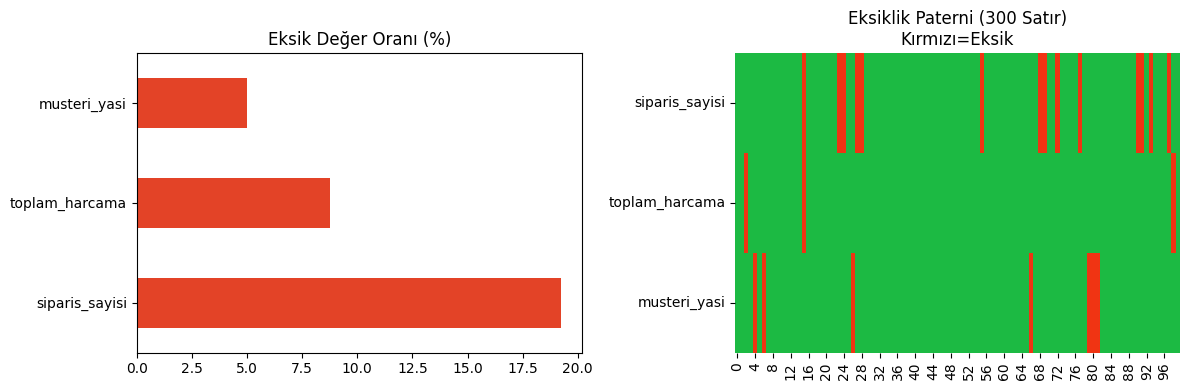

In [17]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
eksik.plot(kind="barh", ax=axes[0], color= "#e34327")
axes[0].set_title("Eksik Değer Oranı (%)")

sns.heatmap(
    df[eksik.index].head(100).isnull().T,
    ax=axes[1], cmap=["#1cba43", "#f03413"], cbar=False
)

axes[1].set_title("Eksiklik Paterni (300 Satır)\nKırmızı=Eksik")
plt.tight_layout() #grafiklerin üst üste binmesini engeller
plt.show() #grafiği ekrana basar

In [20]:
def siniflandir(df, col):
  eksik_flag = df[col].isnull().astype(int)
  sayisal_sutunlar = df.select_dtypes("number").columns.drop(col, errors="ignore")

  for i in sayisal_sutunlar:
    mask = df[i].notna()
    if mask.sum() < 30:
      continue
    _, p = stats.pointbiserialr(eksik_flag[mask], df.loc[mask, i])
    if p < 0.05:
      return f"MAR ('{i}' ile ilişkili, p={p:.4f} )"

  if col in df.select_dtypes("number").columns:
    tam = df[col].dropna()
    if (df[df[col] >= tam.quantile(0.8)] [col].isnull().mean()) > 0.15:
      return "MNAR (uç değerler daha fazla eksik)"

  return "MCAR (rastgele eksiklik)"

for col in ["musteri_yasi", "toplam_harcama", "siparis_sayisi"]:
  pct = df[col].isnull().mean() * 100
  print(f"{col:20s} %{pct:.1f} -> {siniflandir(df, col)}")

musteri_yasi         %5.0 -> MCAR (rastgele eksiklik)
toplam_harcama       %8.7 -> MAR ('aylik_gelir' ile ilişkili, p=0.0000 )
siparis_sayisi       %19.2 -> MCAR (rastgele eksiklik)
